 ## Figure 4 Code to Produce Figures



 This figure will focus on the presentation of Further Analysis of Extracted Assemblies.

In [1]:
# importing packages
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
import pickle
import scipy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import squareform, pdist
import scipy.io
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from difflib import diff_bytes
import seaborn as sns
import h5py
import scipy
import os
import upsetplot
import ptitprince
import matplotlib.cm as cm
from statsmodels.stats.multitest import multipletests
plt.rcParams.update({'font.size': 18})
plt.rcParams["figure.figsize"] = (10,10)

# import v1dd_physiology.data_fetching as daf
# from statannotations.Annotator import Annotator

from matplotlib.colors import LinearSegmentedColormap

paired_blue0 = cm.get_cmap('Paired')(0)
paired_blue1 = cm.get_cmap('Paired')(1)

colors1 = ['grey', (.4, .6, .8, .5)]
colors2 = ['grey', (.2, .3, .5, .5), (.4, .6, .8, .5), 'white']
colors3 = [(.2, .3, .5, .5), 'white']
colors4 = ['grey', (.2, .3, .5, .5), (.4, .6, .8, .5),]
colors5 = [(.2, .3, .5, .5), (.4, .6, .8, .5), 'white']
colors6 = ['grey', 'steelblue', (.4, .6, .8, .5),]
colors7 = ['grey', 'steelblue']
colors8 = ['grey', 'cornflowerblue']
colors9 = ['grey', paired_blue1]
colors10 = ['dimgrey', paired_blue0]
greymap = LinearSegmentedColormap.from_list(
        "Custom", colors10, N=80) 

import ptitprince as pt

/var/folders/pf/3jc_0npn76z9n_c1pvb23kp00000gn/T/ipykernel_28709/4214022040.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  paired_blue0 = cm.get_cmap('Paired')(0)
/var/folders/pf/3jc_0npn76z9n_c1pvb23kp00000gn/T/ipykernel_28709/4214022040.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  paired_blue1 = cm.get_cmap('Paired')(1)


 ### Functional Connectivity Analysis


In [2]:
### Functions relevant for Oracle Score Analysis

def distance(x, y):
    return math.sqrt((x[0]-y[0])**2 + (x[1]-y[1])**2)

# def process(img):
#     img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     img_canny = cv2.Canny(img_gray, 0, 50)
#     img_dilate = cv2.dilate(img_canny, None, iterations=1)
#     img_erode = cv2.erode(img_dilate, None, iterations=1)
#     return img_erode

def get_assembly_time_trace(coactivity_trace, scores_in_order, name='scored_time_trace'):
    # Set up three subplots
    num_assemblies = coactivity_trace.shape[1]
    fig, ax = plt.subplots(num_assemblies, 1, figsize=(12, 12))

    # plot
    for i in range(num_assemblies):
        ax[i].plot(coactivity_trace[:, i], color='green')
        ax[i].set_ylabel(f"{scores_in_order[i]:.2}")
        ax[i].set_xlabel("Time Steps")
        ax[i].grid()

    fig.suptitle("Assembly Time Trace")
    #plt.savefig(f"oracle_dists2/assemblies_esteps_150000_affinity_04_{name}.png", dpi = 1200)


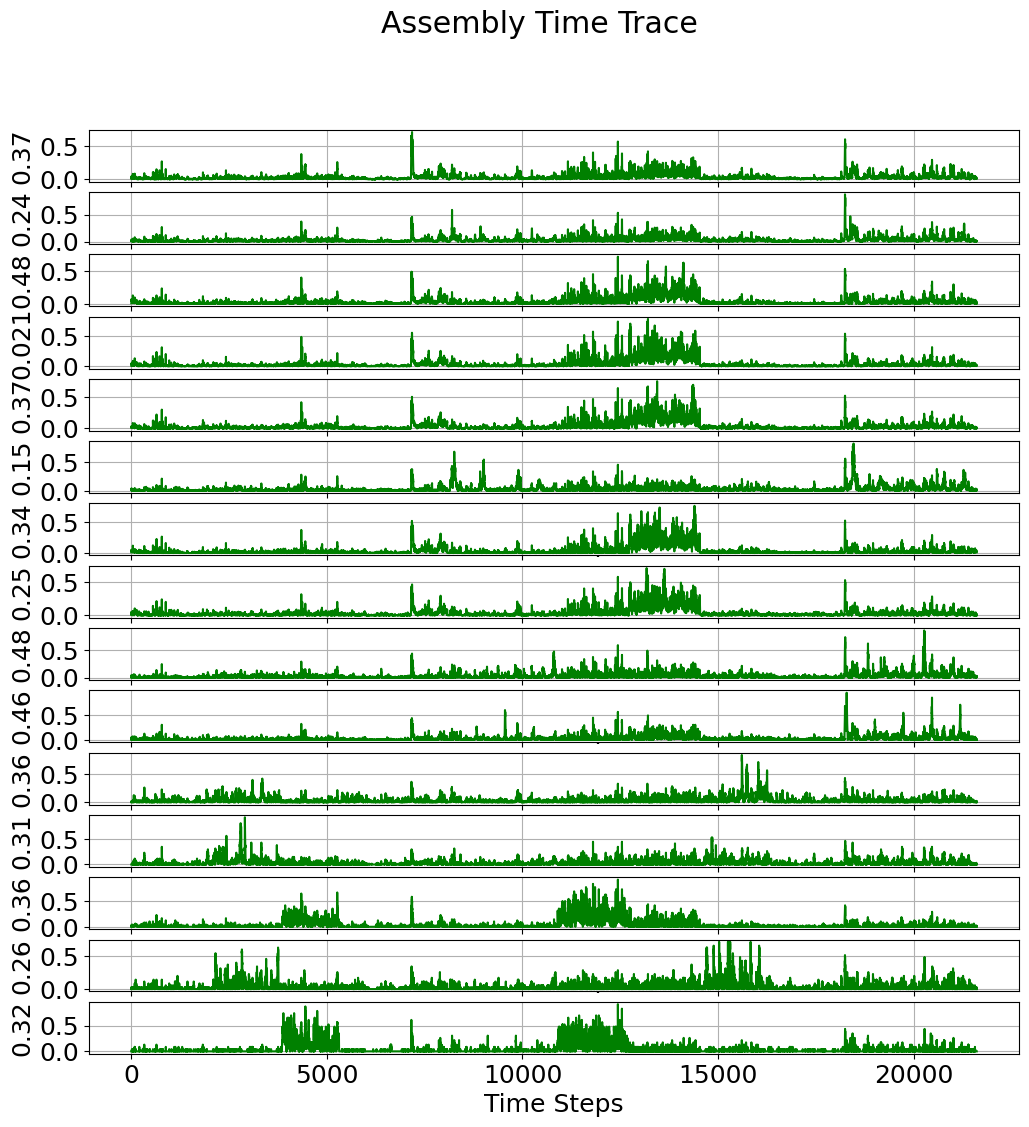

In [3]:
ACTIVITY_RASTER = scipy.io.loadmat(
    "../Figure4/data_files/v1dd/functional/final/esteps_150000_affinity_04_sessionM409828_13_ACTIVITY-RASTER.mat", struct_as_record=True, squeeze_me=True)
SGC_ASSEMBLIES = scipy.io.loadmat(
    "../Figure4/data_files/v1dd/functional/final/esteps_150000_affinity_04_sessionM409828_13_SGC-ASSEMBLIES.mat", struct_as_record=True, squeeze_me=True)

#print(ACTIVITY_RASTER.keys())

activity_raster = ACTIVITY_RASTER['activity_raster']
activity_raster_peaks = ACTIVITY_RASTER['activity_raster_peaks']

coactivity_trace = activity_raster.mean(axis=1)

assemblies = SGC_ASSEMBLIES['assemblies']

# Ensure correct indexing (convert 1-based to 0-based)
assemblies = [np.array(A) - 1 for A in assemblies]
assemblies.sort(key = len)
assemblies.reverse()

# for assembly in assemblies:
#     print(np.max(assembly))
#     print(np.min)

assembly_coactivity_trace = np.vstack(
    [activity_raster[:, A].mean(axis=1) for A in assemblies]).T

scores_in_order = np.load('../Figure4/data_files/v1dd/functional/final/assemblies_esteps_150000_affinity_04_session13_natural_movie_oracle_scores.npy')
get_assembly_time_trace(assembly_coactivity_trace, scores_in_order)


In [4]:
activity_raster.shape

(21616, 2708)

In [5]:
assemblies[0]

array([  11,   12,   25, ..., 2702, 2705, 2706])

In [6]:

def build_neuron_membership(assemblies, num_neurons):
    """
    Establish neuron to assembly membership. Should match LSMM Data.

    Parameters
    ----------
    assemblies: list of arrays, each containing neuron indices in that assembly.
    num_neurons: total number of neurons (should be same as activity_raster.shape[1])

    Returns
    -------
    neuron_to_assemblies : list of sets
        neuron_to_assemblies[i] = set of assembly IDs that neuron i belongs to.
    """
    neuron_to_assemblies = [set() for _ in range(num_neurons)]
    for a_idx, assembly in enumerate(assemblies):
        for n in assembly:
            neuron_to_assemblies[n].add(a_idx)
    return neuron_to_assemblies


def compute_pairwise_correlations(activity_raster, assemblies):
    """
    Compute pairwise correlations for shared assembly neurons, disjoint assembly neurons, and all neurons.

    Parameters
    ----------
    activity_raster : array, shape (T, N)
        Time x Neurons activity matrix.
    assemblies : list of arrays
        Each element has neuron indices for that assembly.

    Returns
    -------
    shared_corrs, disjoint_corrs, all_corrs : 1D np.ndarrays
    """
    T, num_neurons = activity_raster.shape
    print(f"activity_raster shape: T={T}, N={num_neurons}")

    neuron_to_assemblies = build_neuron_membership(assemblies, num_neurons)

    # Compute full correlation matrix across neurons
    print("Computing correlation matrix.")
    corr_mat = np.corrcoef(activity_raster, rowvar=False)  # shape (N, N)

    shared_corrs = []
    disjoint_corrs = []
    all_corrs = []

    print("Partitioning correlations into shared vs disjoint.")
    for i in range(num_neurons):
        Ai = neuron_to_assemblies[i]
        # slice once to make later computation faster
        row = corr_mat[i, i+1:]
        for offset, c in enumerate(row, start=i+1):
            j = offset
            if not np.isfinite(c):
                continue  # skip NaN or infinite correlations
            all_corrs.append(c) # always add correlation, then split
            Aj = neuron_to_assemblies[j]
            if Ai & Aj:  # if non-empty intersection exists
                shared_corrs.append(c)
            else:
                disjoint_corrs.append(c)

    shared_corrs = np.asarray(shared_corrs, dtype=float)
    disjoint_corrs = np.asarray(disjoint_corrs, dtype=float)
    all_corrs = np.asarray(all_corrs, dtype=float)

    print(f"# shared pairs:   {len(shared_corrs)}")
    print(f"# disjoint pairs: {len(disjoint_corrs)}")
    print(f"# all pairs:      {len(all_corrs)}")

    return shared_corrs, disjoint_corrs, all_corrs


def make_raincloud(shared_corrs, disjoint_corrs, all_corrs,
                   title="Pairwise Correlation Distributions Among Assembly Membership"):
    """
    Make a RainCloud-style plot (shared vs disjoint vs all pairs).

    """
    corr_values = np.concatenate([shared_corrs, disjoint_corrs, all_corrs])
    groups = ([f"Shared\nAssembly\nCells\nn={len(shared_corrs)}"] * len(shared_corrs) +
              [f"Disjoint\nAssembly\nCells\nn={len(disjoint_corrs)}"] * len(disjoint_corrs) +
              [f"All\nCells\nn={len(all_corrs)}"] * len(all_corrs))

    data = pd.DataFrame({"Cell Grouping": groups, "Activity Correlation": corr_values})

    # Create a figure
    plt.figure(figsize=(12,8))
    sns.set_theme(style="whitegrid")
    ax = pt.RainCloud(
            x="Cell Grouping",
            y="Activity Correlation",
            data=data,
            palette=[(.4, .6, .8, .5), 'grey'],
            width_viol=0.6,  # Adjust violin width
            alpha=0.8,  # Transparency of the cloud
            move=0.1,  # Adjust position of violins
            point_size = 6,
            orient="v",  # Horizontal orientation
            linewidth=2
            )

    ax.set_title(title, size = 20)
    ax.set_ylabel("Pairwise Pearson correlation", size = 18)
    ax.set_xlabel("Correlation (r)", size = 18)
    ax.tick_params(axis='both', labelsize=16)
    plt.tight_layout()

    plt.ylim(-0.1, 1) 

    # # Add significance stars
    for p_index, p_value in enumerate([0,0]):
        if p_value < 0.001:
            significance = 'P < 0.001\n***'
        elif p_value < 0.01:
            significance = 'P < 0.01\n**'
        elif p_value < 0.05:
            significance = 'P < 0.05\n*'
        else:
            significance = 'ns'

        # Add p-value annotation
        if p_index == 0:
            p_offset = 0.5
            p_height = .9
        elif p_index > 0 and p_index < 4:
            p_offset = 0.5 + p_index
            p_height = .9
        elif p_index == 4:
            p_offset = 2.5
            p_height = 0.5
        elif p_index == 5:
            p_offset = 3.5
            p_height = 0.5

        ax.text(p_offset, p_height, f'{significance}', 
                    color='black', ha='center', va='bottom', fontsize=16, weight='bold')
        
    plt.show()


In [7]:
shared_corrs, disjoint_corrs, all_corrs = compute_pairwise_correlations(
    activity_raster,
    assemblies
)

activity_raster shape: T=21616, N=2708
Computing correlation matrix.
Partitioning correlations into shared vs disjoint.
# shared pairs:   770553
# disjoint pairs: 2894725
# all pairs:      3665278


In [8]:
print("means:", np.mean(shared_corrs), np.mean(disjoint_corrs), np.mean(all_corrs))
print("medians:", np.median(shared_corrs), np.median(disjoint_corrs), np.median(all_corrs))

means: 0.06874232520371443 0.03674305498185759 0.04347027558211281
medians: 0.06295974098746249 0.03453822136270353 0.039956435423060724


In [9]:
print(stats.ranksums(shared_corrs, all_corrs))
print(stats.ranksums(shared_corrs, disjoint_corrs))


RanksumsResult(statistic=525.8760298983069, pvalue=0.0)
RanksumsResult(statistic=650.9793392575029, pvalue=0.0)


/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1070: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:779: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


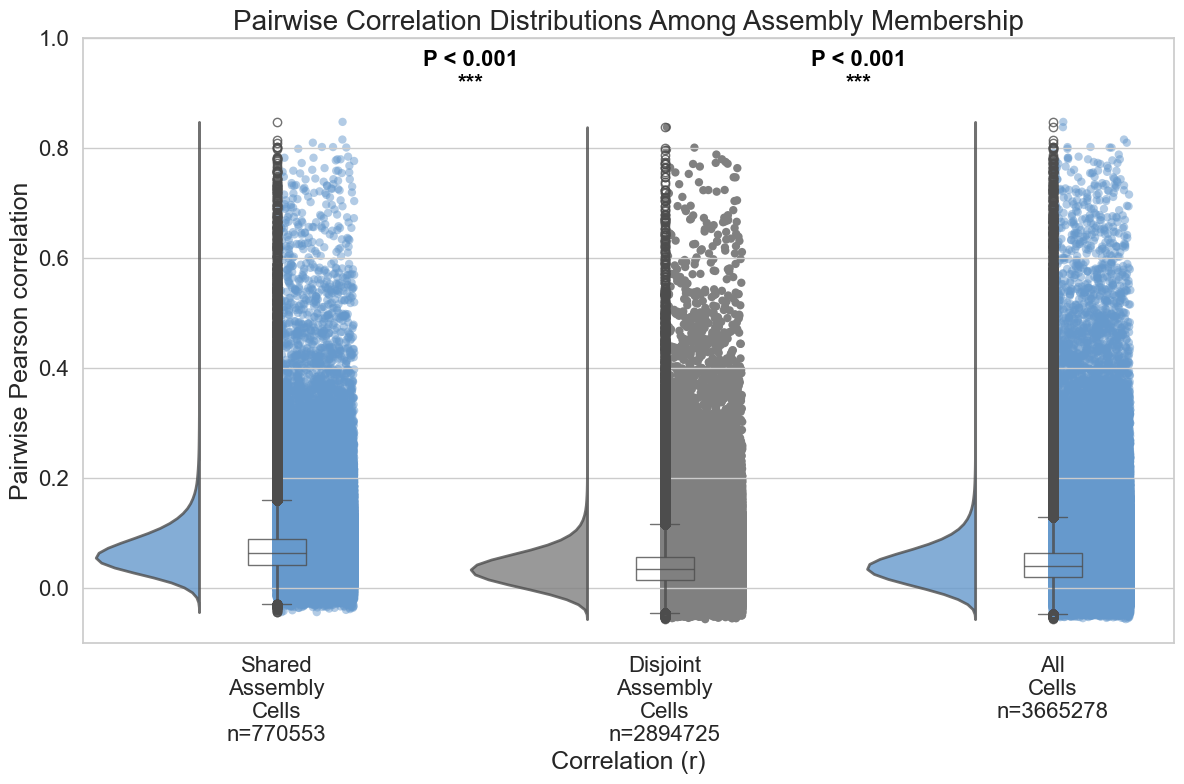

In [10]:
make_raincloud(shared_corrs, disjoint_corrs, all_corrs)

### Work on Noise Correlations

In [11]:
assembly_coactivity_trace = np.vstack(
    [activity_raster[:, A-1].mean(axis=1) for A in assemblies]).T
assembly_mapping = pd.read_pickle('../Figure2/map_ordered_to_sgc_output.pickle')

In [12]:
T, N = activity_raster.shape
print(f"Activity raster shape: T={T}, N={N}, n_assemblies={len(assemblies)}")

Activity raster shape: T=21616, N=2708, n_assemblies=15


In [13]:
nwb_f = h5py.File('../../data_files/v1dd/functional/final/M409828_13_20181213.nwb', 'r')
presentation = nwb_f['stimulus']['presentation']

In [14]:
nm_timestamps = np.array(presentation['natural_movie'].get('timestamps'))
nm_data = np.array(presentation['natural_movie'].get('data'))
noise_timestamps = np.array(presentation['locally_sparse_noise'].get('timestamps'))
noise_data = np.array(presentation['locally_sparse_noise'].get('data'))

In [15]:
np.unique(nm_data[:,2], return_inverse = True)

(array([0.000e+00, 1.000e+00, 2.000e+00, ..., 3.597e+03, 3.598e+03,
        3.599e+03], dtype=float32),
 array([  0,   1,   2, ..., 897, 898, 899]))

In [16]:
assembly_timesteps = np.load('../../data_files/v1dd/functional/final/sessionM409828_13_f_ts.npy')
assembly_timesteps_start = assembly_timesteps[0]
assembly_timesteps_end = assembly_timesteps[-1]

frame_ts = assembly_timesteps

In [17]:
def build_stim_response_matrix(activity, frame_ts, stim_data):
    """
    Build response matrix [stimulus x trial x neuron] from activity.

    Parameters
    ----------
        activity: (T, N) array (for neurons)
        frame_ts: (T,) timestamps of imaging frames
        stim_data: (P, 3): [start_time, end_time, stim_id]

    Returns
    ----------
        responses: (S, R_max, N) with NaNs for missing trials
        stim_ids: (S,) unique stimulus IDs
        trial_counts: (S,) number of valid trials per stimulus
    """
    T, N = activity.shape
    starts = stim_data[:, 0]
    ends = stim_data[:, 1]
    ids = stim_data[:, 2].astype(int)

    stim_ids, inv = np.unique(ids, return_inverse=True)  # map each row -> condition index
    S = len(stim_ids)

    trial_counts = np.bincount(inv, minlength=S)
    R_max = trial_counts.max()

    responses = np.full((S, R_max, N), np.nan, dtype=float)
    trial_counter = np.zeros(S, dtype=int)

    for p in range(len(stim_data)):
        s_idx = inv[p]
        r_idx = trial_counter[s_idx]

        t_mask = (frame_ts >= starts[p]) & (frame_ts <= ends[p]) # imaging frames in this stimulus window
        if not np.any(t_mask):
            continue

        resp = activity[t_mask, :].mean(axis=0)  # (N,)
        responses[s_idx, r_idx, :] = resp
        trial_counter[s_idx] += 1

    # update trial counts to only include what overlaps with imaging
    trial_counts = trial_counter.copy()
    
    return responses, stim_ids, trial_counts

In [18]:
# Build stimulus-response matrices for NEURONS
nm_neuron_resp, nm_ids, nm_trial_counts = build_stim_response_matrix(
    activity_raster, frame_ts, nm_data
)
noise_neuron_resp, noise_ids, noise_trial_counts = build_stim_response_matrix(
    activity_raster, frame_ts, noise_data
)

In [19]:
nm_neuron_resp.shape, noise_neuron_resp.shape

((3600, 9, 2708), (1593, 2, 2708))

In [20]:
def compute_signal_noise_corr(responses, trial_counts):
    """
    Compute signal and noise correlation matrices from response matrix.

    Parameters
    ----------
        responses: (S, R_max, N) with NaNs for missing trials
        trial_counts: (S,) number of valid trials per stimulus

    Returns
    ----------
        signal_corr: (N, N) correlation of tuning curves across stimuli
        noise_corr: (N, N) correlation of residuals across (stim, trial)
    """
    S, R_max, N = responses.shape

    # Valid trial mask: true where all neurons are finite
    valid_mask = np.isfinite(responses).all(axis=2)  # (S, R_max)

    # Signal computation
    tuning = np.full((S, N), np.nan)
    for s in range(S):
        if trial_counts[s] == 0:
            continue
        trials_s = valid_mask[s]
        if not np.any(trials_s):
            continue
        tuning[s, :] = responses[s, trials_s, :].mean(axis=0)

    good_stim = np.isfinite(tuning).all(axis=1)
    tuning_good = tuning[good_stim, :]
    if tuning_good.shape[0] < 2:
        raise RuntimeError("Not enough stimuli with valid responses to compute signal correlations.")

    signal_corr = np.corrcoef(tuning_good, rowvar=False)  # (N, N)

    # Residual (noise) computation
    residual_list = []
    for s in range(S):
        if trial_counts[s] < 2:
            continue
        if not np.isfinite(tuning[s, :]).all():
            continue
        trials_s = valid_mask[s]
        if trials_s.sum() < 2:
            continue
        resp_s = responses[s, trials_s, :]       # (n_trials_s, N)
        resid_s = resp_s - tuning[s, :]          # broadcast over trials
        residual_list.append(resid_s)

    if len(residual_list) == 0:
        print("Warning: no stimuli with >=2 valid trials; noise correlations will be NaN.")
        noise_corr = np.full_like(signal_corr, np.nan, dtype=float)
    else:
        all_resid = np.vstack(residual_list)      # (M, N)
        noise_corr = np.corrcoef(all_resid, rowvar=False)

    return signal_corr, noise_corr


def extract_pairwise_corrs(corr_mat, neuron_to_assemblies):
    """
    Flatten correlation matrix into distributions for all cell pairs, shared assembly pairs, and disjoint assemlby pairs.

    Parameters
    ----------
        corr_mat: (N, N)
        neuron_to_assemblies: list of sets, len N

    Returns
    ----------
        dict with keys referring to all the correlation values
    """
    N = corr_mat.shape[0]
    all_vals = []
    shared_vals = []
    disjoint_vals = []

    for i in range(N):
        Ai = neuron_to_assemblies[i]
        row = corr_mat[i, i+1:]
        for offset, c in enumerate(row, start=i+1):
            j = offset
            if not np.isfinite(c):
                continue
            all_vals.append(c)
            Aj = neuron_to_assemblies[j]
            if Ai & Aj:
                shared_vals.append(c)
            else:
                disjoint_vals.append(c)

    all_vals = np.asarray(all_vals, float)
    shared_vals = np.asarray(shared_vals, float)
    disjoint_vals = np.asarray(disjoint_vals, float)

    return {f"All\nCells\n(n={len(all_vals)})": all_vals, f"Shared\nAssembly\nCells\n(n={len(shared_vals)})": shared_vals, f"Disjoint\nAssembly\nCells\n(n={len(disjoint_vals)})": disjoint_vals}

In [21]:
print("Computing NEURON-LEVEL correlations for natural_movie...")
nm_signal_corr, nm_noise_corr = compute_signal_noise_corr(
    nm_neuron_resp, nm_trial_counts
)
print(f"\t\t\tDONE WITH NATURAL MOVIES.")
print("Computing NEURON-LEVEL correlations for locally_sparse_noise...")
lsn_signal_corr, lsn_noise_corr = compute_signal_noise_corr(
    noise_neuron_resp, noise_trial_counts
)
print(f"\t\t\tDONE WITH NOISE.")

Computing NEURON-LEVEL correlations for natural_movie...


/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


			DONE WITH NATURAL MOVIES.
Computing NEURON-LEVEL correlations for locally_sparse_noise...
			DONE WITH NOISE.


In [22]:
neuron_to_assemblies = build_neuron_membership(assemblies, N)
print("These many neurons are found in no assemlbies:", len(np.where(np.array(neuron_to_assemblies) == set())[0]))

These many neurons are found in no assemlbies: 757


In [23]:
nm_signal_pairs = extract_pairwise_corrs(
        nm_signal_corr, neuron_to_assemblies,
)
nm_noise_pairs = extract_pairwise_corrs(
    nm_noise_corr, neuron_to_assemblies,
)

lsn_signal_pairs = extract_pairwise_corrs(
    lsn_signal_corr, neuron_to_assemblies,
)
lsn_noise_pairs = extract_pairwise_corrs(
    lsn_noise_corr, neuron_to_assemblies,
)

In [24]:
def plot_raincloud_pairwise(df, stim_label, save_figure = False):
    """
    Make a RainCloud-style plot of pairwise correlations for the given stimulus type.

    Parameters
    ----------
    df: DataFrame with columns:
        'stim', 'corr_type' ('signal'/'noise'),
        'pair_type' ('all'/'shared'/'disjoint'), 'corr'
    stim_label: 'natural_movie' or 'locally_sparse_noise'
    """
    sns.set_theme(style="whitegrid")
    sub = df[df["stim"] == stim_label].copy()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    for ax, ctype in zip(axes, ["signal", "noise"]):
        sub_c = sub[sub["corr_type"] == ctype]
        if len(sub_c) == 0:
            ax.text(0.5, 0.5, f"No data for {ctype}", ha="center", va="center")
            ax.set_axis_off()
            continue

        pt.RainCloud(
            x="pair_type",
            y="corr",
            data=sub_c,
            ax=ax,
            width_viol=0.4,
            width_box=0.3,
            move=0.2,
            alpha=0.7,
            pointplot=True)

        ax.set_title(f"{stim_label} – {ctype} correlations", size = 20)
        ax.set_xlabel("Pair Type", size = 18)
        ax.set_ylabel("Pairwise Pearson correlation" if ctype == "signal" else "", size = 18)
        ax.tick_params(axis='both', labelsize=16)

        # # Add significance stars
        for p_index, p_value in enumerate([0,0]):
            if p_value < 0.001:
                significance = 'P < 0.001\n***'
            elif p_value < 0.01:
                significance = 'P < 0.01\n**'
            elif p_value < 0.05:
                significance = 'P < 0.05\n*'
            else:
                significance = 'ns'

            # Add p-value annotation
            if p_index == 0:
                p_offset = 0.5
                p_height = 1
            elif p_index > 0 and p_index < 4:
                p_offset = 0.5 + p_index
                p_height = 1
            elif p_index == 4:
                p_offset = 2.5
                p_height = 0.5
            elif p_index == 5:
                p_offset = 3.5
                p_height = 0.5

            ax.text(p_offset, p_height, f'{significance}', 
                        color='black', ha='center', va='bottom', fontsize=16, weight='bold')

    if stim_label == 'natural_movie':
        stim_title = 'Natural Movies'
    else:
        stim_title = 'White Noise'

    fig.suptitle(f"Pairwise Signal vs Noise correlations Among Assembly Membership ({stim_title})", y=1.01, size = 18)
    plt.ylim(None, 1.19)
    plt.tight_layout()

    if save_figure:
        plt.savefig(f'./Signal_vs_Noise_Correlations_{stim_label}.pdf', dpi=300)

    plt.show()

In [25]:
# build a long records dictionary for all the data
records = []

def add_records(stim_label, corr_type, pair_dict):
    for ptype, vals in pair_dict.items():
        for v in vals:
            records.append(
                {
                    "stim": stim_label,
                    "corr_type": corr_type,
                    "pair_type": ptype,
                    "corr": float(v),
                }
            )

add_records("natural_movie", "signal", nm_signal_pairs)
add_records("natural_movie", "noise", nm_noise_pairs)
add_records("locally_sparse_noise", "signal", lsn_signal_pairs)
add_records("locally_sparse_noise", "noise", lsn_noise_pairs)

df_pairs = pd.DataFrame.from_records(records)
print(df_pairs.groupby(["stim", "corr_type", "pair_type"]).size())

stim                  corr_type  pair_type                             
locally_sparse_noise  noise      All\nCells\n(n=3265290)                   3265290
                                 Disjoint\nAssembly\nCells\n(n=2553633)    2553633
                                 Shared\nAssembly\nCells\n(n=711657)        711657
                      signal     All\nCells\n(n=3638253)                   3638253
                                 Disjoint\nAssembly\nCells\n(n=2869671)    2869671
                                 Shared\nAssembly\nCells\n(n=768582)        768582
natural_movie         noise      All\nCells\n(n=3643650)                   3643650
                                 Disjoint\nAssembly\nCells\n(n=2878985)    2878985
                                 Shared\nAssembly\nCells\n(n=764665)        764665
                      signal     All\nCells\n(n=3659865)                   3659865
                                 Disjoint\nAssembly\nCells\n(n=2890027)    2890027
               

/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(


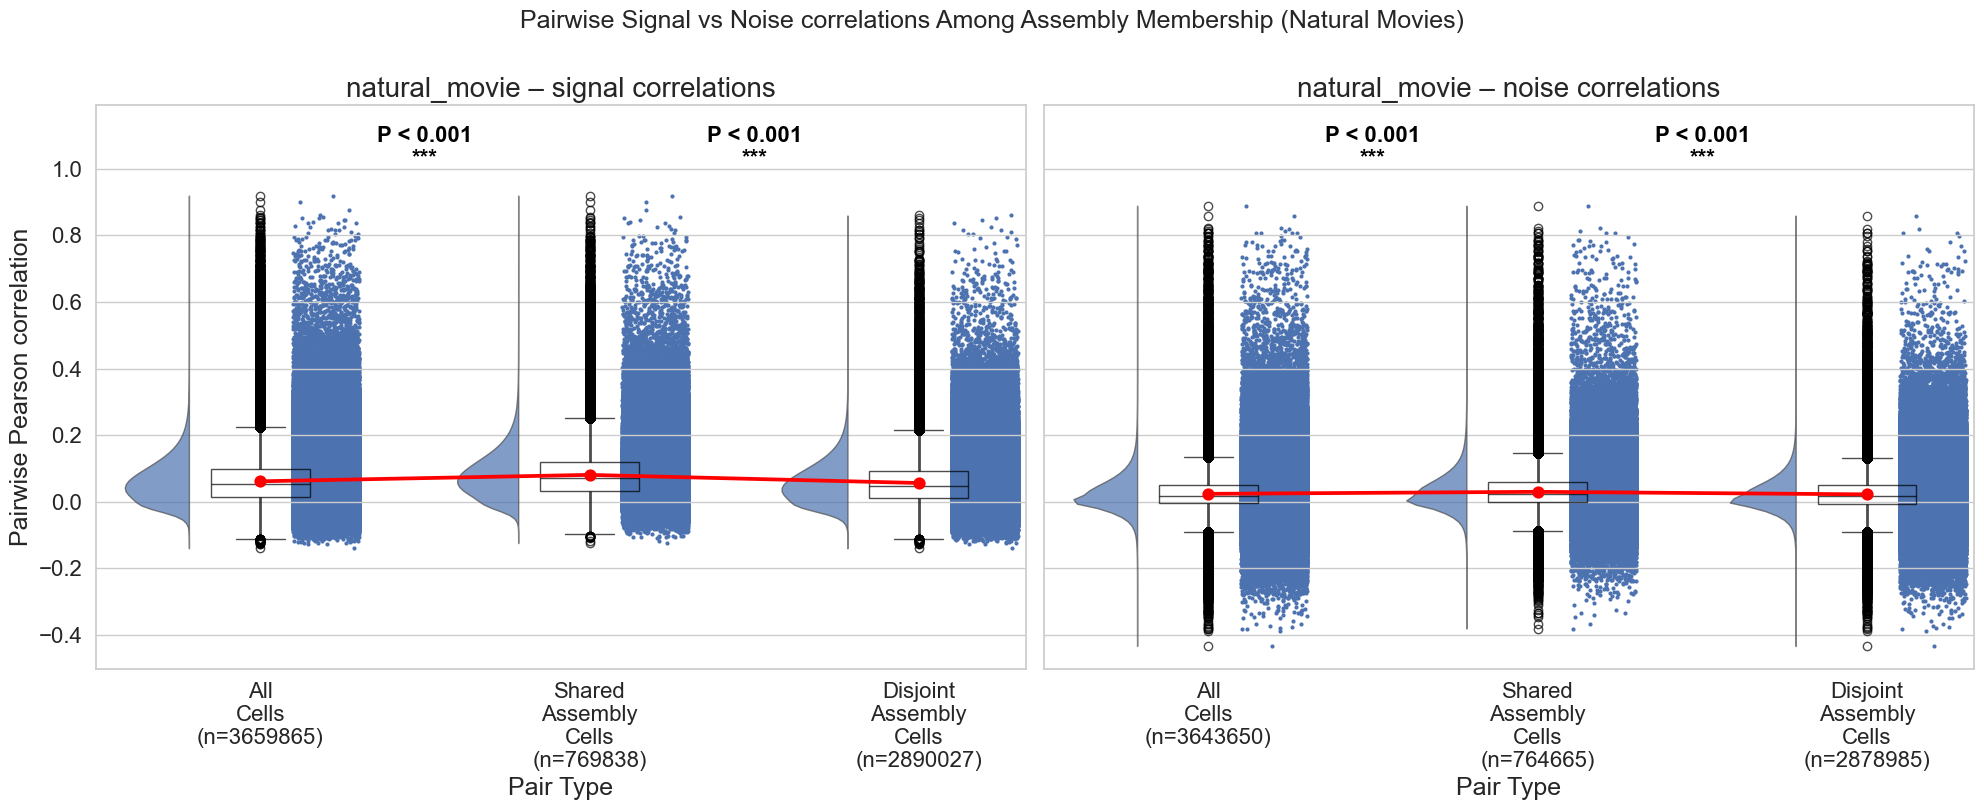

In [26]:
plot_raincloud_pairwise(df_pairs, "natural_movie", save_figure = True)

/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(
/opt/anaconda3/envs/assembly/lib/python3.10/site-packages/ptitprince/PtitPrince.py:1143: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.0}` instead.

  sns.pointplot(


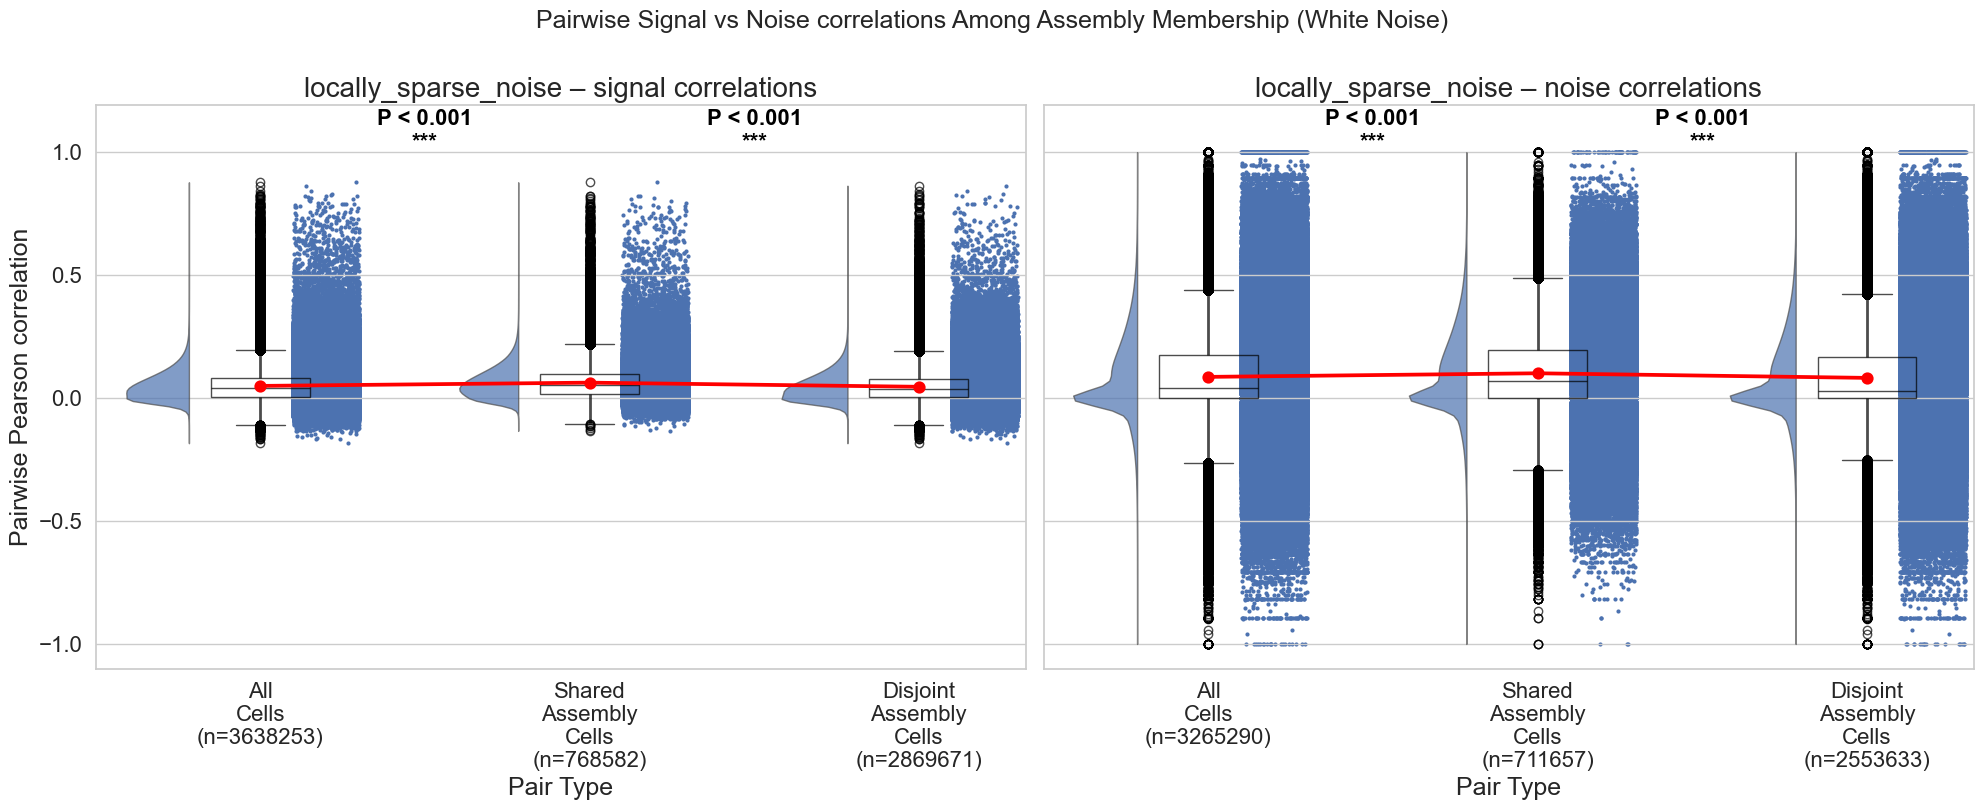

In [27]:
plot_raincloud_pairwise(df_pairs, "locally_sparse_noise")

In [28]:
df_pairs

,stim,corr_type,pair_type,corr
0,natural_movie,signal,All\nCells\n(n=3659865),0.602952
1,natural_movie,signal,All\nCells\n(n=3659865),-0.078579
2,natural_movie,signal,All\nCells\n(n=3659865),0.137117
3,natural_movie,signal,All\nCells\n(n=3659865),-0.033611
4,natural_movie,signal,All\nCells\n(n=3659865),-0.121053
...,...,...,...,...
28414111,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2553633),-0.136931
28414112,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2553633),-0.138675
28414113,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2553633),0.158114
28414114,locally_sparse_noise,noise,Disjoint\nAssembly\nCells\n(n=2553633),-0.080064


In [29]:
np.unique(df_pairs['pair_type'].values)[0]

'All\nCells\n(n=3265290)'

In [30]:
sub = df_pairs[(df_pairs["stim"] == "natural_movie") &
                   (df_pairs["corr_type"] == "signal")].copy()


In [31]:
np.unique(sub['pair_type'].values)

array(['All\nCells\n(n=3659865)',
       'Disjoint\nAssembly\nCells\n(n=2890027)',
       'Shared\nAssembly\nCells\n(n=769838)'], dtype=object)

In [32]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# def bh_fdr(pvals, alpha=0.05):
#     pvals = np.asarray(pvals, float)
#     m = len(pvals)
#     order = np.argsort(pvals)
#     ranked_p = pvals[order]

#     # BH: p_(i) * m / i
#     q = ranked_p * m / np.arange(1, m+1)
#     # enforce monotonicity
#     q = np.minimum.accumulate(q[::-1])[::-1]
#     pvals_corrected = np.empty_like(q)
#     pvals_corrected[order] = q
#     reject = pvals_corrected <= alpha
#     return reject, pvals_corrected

def pairwise_mwu_for_stim(df_pairs, stim_label, corr_type,
                          subsample_per_group=None, random_state=0):
    """
    Run pairwise Mann-Whitney U tests on correlation distributions for a given
    stimulus and correlation type.

    df_pairs: DataFrame with columns 'stim', 'corr_type', 'pair_type', 'corr'
    stim_label: e.g. "natural_movie"
    corr_type: "signal" or "noise"
    subsample_per_group: int or None (optional extra thinning)
    """
    rng = np.random.default_rng(random_state)

    sub = df_pairs[(df_pairs["stim"] == stim_label) &
                   (df_pairs["corr_type"] == corr_type)].copy()

    group_vals = {}
    # pairs_type = ["All Cells ***", "Disjoint Assembly ***","Shared Assembly ***"]
    pairs_type = np.unique(sub['pair_type'].values)
    for ptype in pairs_type:
        arr = sub.loc[sub["pair_type"] == ptype, "corr"].to_numpy()
        if subsample_per_group is not None and len(arr) > subsample_per_group:
            idx = rng.choice(len(arr), size=subsample_per_group, replace=False)
            arr = arr[idx]
        group_vals[ptype] = arr

    # Defining the comparisons that will be run
    comparisons = [
        (pairs_type[0], pairs_type[1]),
        (pairs_type[0], pairs_type[2]),
        (pairs_type[2], pairs_type[1]),
    ]

    results = []
    raw_pvals = []

    for g1, g2 in comparisons:
        x = group_vals[g1]
        y = group_vals[g2]
        n1, n2 = len(x), len(y)
        if n1 == 0 or n2 == 0:
            print(f"Skipping {g1} vs {g2} for {stim_label}, {corr_type}: empty group.")
            continue

        # Statistical Test
        U, p = mannwhitneyu(x, y, alternative="two-sided", method="asymptotic")
        raw_pvals.append(p)

        # Effect size
        med_diff = np.median(x) - np.median(y)
        # rank-biserial correlation
        r_rb = 2.0 * U / (n1 * n2) - 1.0

        results.append({
            "stim": stim_label,
            "corr_type": corr_type,
            "group1": g1,
            "group2": g2,
            "n1": n1,
            "n2": n2,
            "U": U,
            "p_raw": p,
            "median_diff": med_diff,
            "rank_biserial": r_rb,
        })

    # FDR correction across comparisons
    if len(raw_pvals) > 0:
        _, p_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method="fdr_bh")
        for res, p_corr in zip(results, p_corrected):
            res["p_fdr"] = p_corr

    return pd.DataFrame(results)

In [33]:
# Natural movie signal correlations
nm_sig_res = pairwise_mwu_for_stim(df_pairs,
                                   stim_label="natural_movie",
                                   corr_type="signal",
                                   subsample_per_group=None)

# Natural movie noise correlations
nm_noise_res = pairwise_mwu_for_stim(df_pairs,
                                     stim_label="natural_movie",
                                     corr_type="noise",
                                     subsample_per_group=None)

print("Natural movie – signal:")
print(nm_sig_res)

print("\nNatural movie – noise:")
print(nm_noise_res)

Natural movie – signal:
            stim corr_type                               group1  \
0  natural_movie    signal              All\nCells\n(n=3659865)   
1  natural_movie    signal              All\nCells\n(n=3659865)   
2  natural_movie    signal  Shared\nAssembly\nCells\n(n=769838)   

                                   group2       n1       n2             U  \
0  Disjoint\nAssembly\nCells\n(n=2890027)  3659865  2890027  5.523653e+12   
1     Shared\nAssembly\nCells\n(n=769838)  3659865   769838  1.173653e+12   
2  Disjoint\nAssembly\nCells\n(n=2890027)   769838  2890027  1.347525e+12   

   p_raw  median_diff  rank_biserial  p_fdr  
0    0.0     0.004844       0.044454    0.0  
1    0.0    -0.019094      -0.166884    0.0  
2    0.0     0.023939       0.211339    0.0  

Natural movie – noise:
            stim corr_type                               group1  \
0  natural_movie     noise              All\nCells\n(n=3643650)   
1  natural_movie     noise              All\nCells\n(n=3

In [34]:
# Natural movie signal correlations
nm_sig_res = pairwise_mwu_for_stim(df_pairs,
                                   stim_label="locally_sparse_noise",
                                   corr_type="signal",
                                   subsample_per_group=None)

# Natural movie noise correlations
nm_noise_res = pairwise_mwu_for_stim(df_pairs,
                                     stim_label="locally_sparse_noise",
                                     corr_type="noise",
                                     subsample_per_group=None)

print("Locally Sparse Noise – signal:")
print(nm_sig_res)

print("\nLocally Sparse Noise – noise:")
print(nm_noise_res)

Locally Sparse Noise – signal:
                   stim corr_type                               group1  \
0  locally_sparse_noise    signal              All\nCells\n(n=3638253)   
1  locally_sparse_noise    signal              All\nCells\n(n=3638253)   
2  locally_sparse_noise    signal  Shared\nAssembly\nCells\n(n=768582)   

                                   group2       n1       n2             U  \
0  Disjoint\nAssembly\nCells\n(n=2869671)  3638253  2869671  5.402535e+12   
1     Shared\nAssembly\nCells\n(n=768582)  3638253   768582  1.215907e+12   
2  Disjoint\nAssembly\nCells\n(n=2869671)   768582  2869671  1.285029e+12   

   p_raw  median_diff  rank_biserial  p_fdr  
0    0.0     0.003386       0.034910    0.0  
1    0.0    -0.013369      -0.130344    0.0  
2    0.0     0.016755       0.165254    0.0  

Locally Sparse Noise – noise:
                   stim corr_type                               group1  \
0  locally_sparse_noise     noise              All\nCells\n(n=3265290)   
